#MBAI 5310 - AI Programming: Final Project

By: Abdul Wasay

###Welcome to the Chest X-Ray Pulmonary Disease Classifier!

This model classifies chest X-ray images into six pulmonary disease categories: Covid-19, Emphysema, Normal, Pneumonia-Bacterial, Pneumonia-Viral, and Tuberculosis using a Convolutional Neural Network (CNN).

**Dataset:**
https://www.kaggle.com/datasets/mohamedasak/chest-x-ray-6-classes-dataset

Let's classify some chest X-rays!

In [ ]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt

# Import TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

Debugging:

In [ ]:
# Locating the uploaded zip file
import subprocess
result = subprocess.run(['find', '/', '-name', 'chest-xray.zip', '-type', 'f'],
                        capture_output = True,
                        text = True)
print(result.stdout)

/content/chest-xray.zip



Unzipping the chest-xray.zip Folder:

In [ ]:
# Unzip the dataset into Colab's local storag
import zipfile

# Extract all files into the dataset folder
with zipfile.ZipFile('/content/chest-xray.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [ ]:
# Define paths for training, validation, and test sets
directory = '/content/dataset/chest-xray'

train_directory = os.path.join(directory, 'train')
val_directory = os.path.join(directory, 'val')
test_directory = os.path.join(directory, 'test')

In [ ]:
# Quick check
print("Training images: ", sum([len(files) for _, _, files in os.walk(train_directory)]))
print("Validation images: ", sum([len(files) for _, _, files in os.walk(val_directory)]))
print("Test images: ", sum([len(files) for _, _, files in os.walk(test_directory)]))

Training images:  14551
Validation images:  1748
Test images:  1737


Configuration, Data Augmentation, Load Images:

In [ ]:
# Define key training parameters
img_size = (224, 224)  # All images are already 224 x 224
batch_size = 32
num_classes = 6

In [ ]:
# Randomly alter training images to help the model learn better
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 10,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    zoom_range = 0.1
)

# Validation and test data — only normalize, no augmentation
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
# Load training images from directory
train_generator = train_datagen.flow_from_directory(
    train_directory,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'categorical'
)

Found 14551 images belonging to 6 classes.


In [ ]:
# Load validation images from directory
val_generator = val_datagen.flow_from_directory(
    val_directory,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'categorical'
)

Found 1748 images belonging to 6 classes.


In [ ]:
# Load testing images from directory
test_generator = test_datagen.flow_from_directory(
    test_directory,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 1737 images belonging to 6 classes.


In [ ]:
# Show classes
print("Classes detected:", train_generator.class_indices)

Classes detected: {'Covid-19': 0, 'Emphysema': 1, 'Normal': 2, 'Pneumonia-Bacterial': 3, 'Pneumonia-Viral': 4, 'Tuberculosis': 5}


Building the CNN and Adding Classification Layers:

In [ ]:
# Build the CNN layer by layer
model = keras.Sequential([

    # Block 1: Detects basic features like edges
    layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 2: Detects more complex patterns
    layers.Conv2D(64, (3, 3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 3: Detects higher level features
    layers.Conv2D(128, (3, 3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 4: Detects the most abstract features
    layers.Conv2D(256, (3, 3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Add the final layers for classification
model = keras.Sequential([
    *model.layers,
    layers.Flatten(),
    layers.Dense(256, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation = 'softmax')
])

In [ ]:
# Configure the model for training
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

# Diplay model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,829,318 (37.50 MB)

 Trainable params: 9,828,358 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

Set Up Callbacks:

In [ ]:
# Stop training if the model stops improving
early_stopping = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

In [ ]:
# Save the best version of the model during training
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor = 'val_loss',
    save_best_only = True
)

In [ ]:
# Slow down the learning rate if progress stalls
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience = 3,
    min_lr = 1e-6
)

Training the Model:

In [ ]:
# Train the model on the training data
history = model.fit(
    train_generator,
    epochs = 10,
    validation_data = val_generator,
    callbacks = [early_stopping, checkpoint, reduce_lr]
)

# Quick check
print("Training complete!")

Epoch 1/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 195s 403ms/step - accuracy: 0.4772 - loss: 1.8701 - val_accuracy: 0.2735 - val_loss: 7.2434 - learning_rate: 0.0010
Epoch 2/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 175s 385ms/step - accuracy: 0.5519 - loss: 1.0564 - val_accuracy: 0.2952 - val_loss: 6.0610 - learning_rate: 0.0010
Epoch 3/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 174s 383ms/step - accuracy: 0.5937 - loss: 0.9015 - val_accuracy: 0.1705 - val_loss: 18.4488 - learning_rate: 0.0010
Epoch 4/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 174s 383ms/step - accuracy: 0.6127 - loss: 0.8624 - val_accuracy: 0.5320 - val_loss: 1.3691 - learning_rate: 0.0010
Epoch 5/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 173s 381ms/step - accuracy: 0.6352 - loss: 0.8130 - val_accuracy: 0.2523 - val_loss: 6.3636 - learning_rate: 0.0010
Epoch 6/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 174s 382ms/step - accuracy: 0.6462 - loss: 0.7761 - val_accuracy: 0.7088 - val_loss: 0.6226 - learning_rate: 0.0010
Epoch 7/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 174s 382ms/step - accur

 Extract Training History:

In [ ]:
# Pull accuracy and loss values from the training history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# One value per epoch
epochs_range = range(1, len(train_acc) + 1)

Plot Accuracy:

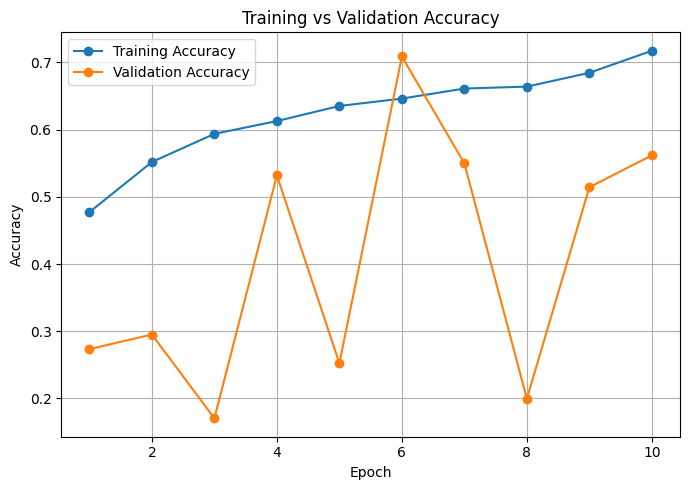

In [ ]:
# Plot training vs validation accuracy
plt.figure(figsize = (7, 5))
plt.plot(epochs_range, train_acc, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs_range, val_acc, label = 'Validation Accuracy', marker = 'o')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

Plot Loss:

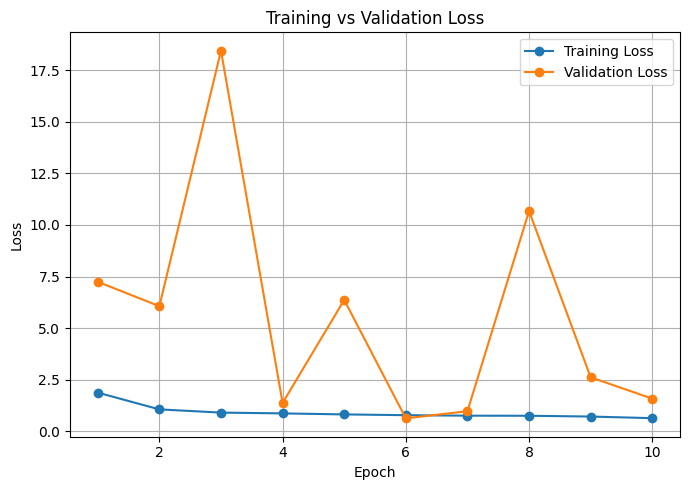

In [ ]:
# Plot training vs validation loss
plt.figure(figsize = (7, 5))
plt.plot(epochs_range, train_loss, label = 'Training Loss', marker = 'o')
plt.plot(epochs_range, val_loss, label = 'Validation Loss', marker = 'o')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

Evaluate on Test Set:

In [ ]:
# Run the model on the test set and print the results
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7363 - loss: 0.6084
Test Loss: 0.6084
Test Accuracy: 73.63%


Generate Predictions:

In [ ]:
# Get the model's predictions on the test set
predictions = model.predict(test_generator)

# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis = 1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step


Classification Report:

In [ ]:
# Print precision, recall and F1-score for each class
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

Classification Report:
                     precision    recall  f1-score   support

           Covid-19       0.74      0.72      0.73       300
          Emphysema       0.69      0.72      0.71       250
             Normal       0.71      0.98      0.82       300
Pneumonia-Bacterial       0.70      0.50      0.58       300
    Pneumonia-Viral       0.59      0.56      0.58       300
       Tuberculosis       1.00      0.94      0.97       287

           accuracy                           0.74      1737
          macro avg       0.74      0.74      0.73      1737
       weighted avg       0.74      0.74      0.73      1737



Confusion Matrix:

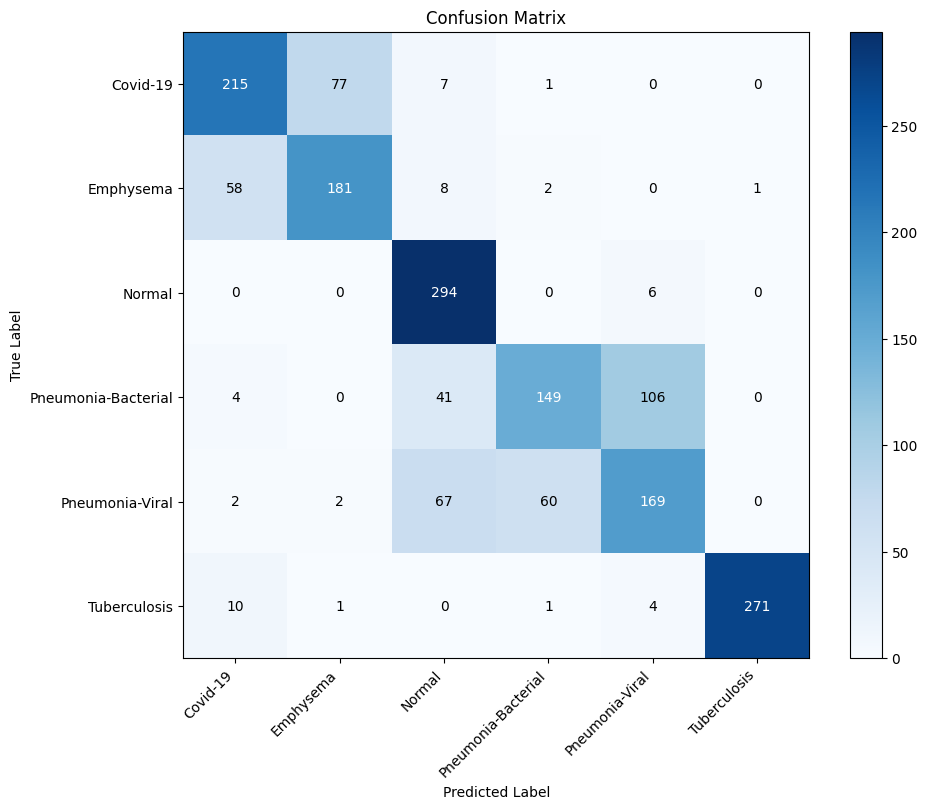

In [ ]:
# Plot the confusion matrix to see where the model is making mistakes
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize = (10, 8))
plt.imshow(cm, interpolation = 'nearest', cmap = plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation = 45, ha = 'right')
plt.yticks(tick_marks, class_labels)

# Add counts inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va = 'center', color = 'white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png')
plt.show()

Load Sample Images:

In [ ]:
# Reset the test generator and grab one batch of images
test_generator.reset()
images, labels = next(test_generator)

Run Predictions:

In [ ]:
# Run the model on the sample images
preds = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step


Display Predictions:

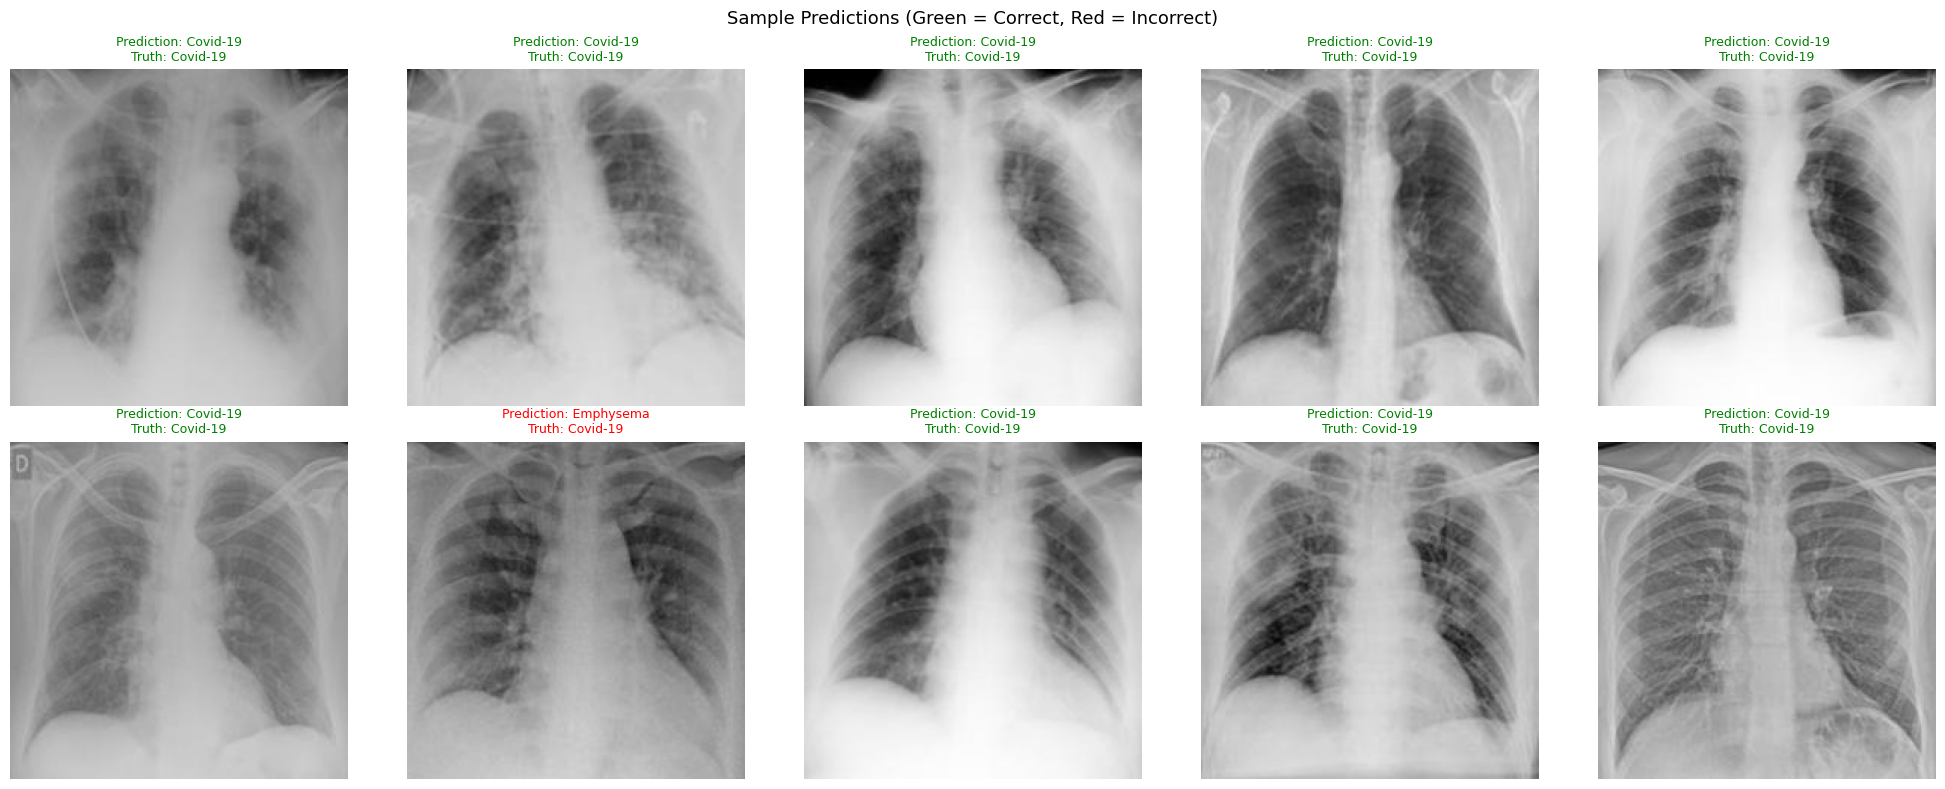

In [ ]:
# Display 10 sample X-rays with their predicted and true labels
plt.figure(figsize = (20, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap = 'gray')

    # Get predicted and true class names
    predicted_label = class_labels[np.argmax(preds[i])]
    true_label = class_labels[np.argmax(labels[i])]

    # Green = correct, Red = incorrect
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"Prediction: {predicted_label}\nTruth: {true_label}", color = color, fontsize = 9)
    plt.axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Incorrect)', fontsize = 13)
plt.tight_layout()
plt.show()